# Segmentação com Mistura de Gaussianas

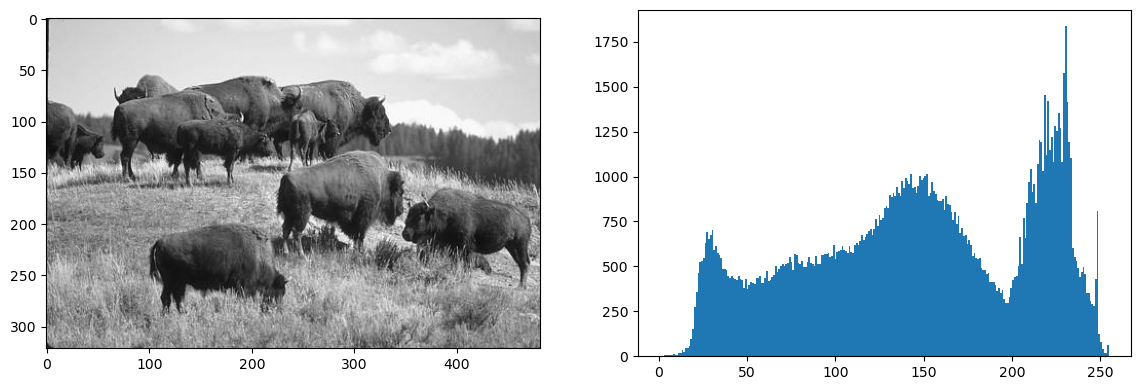

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture

img = plt.imread("../../dados/gnu.jpg")

plt.figure(figsize=[14, 4.5])
plt.subplot(1, 2, 1)
plt.imshow(img, "gray")
plt.subplot(1, 2, 2)
plt.hist(img.ravel(), 255);

In [3]:
# Cria modelo com 3 Gaussianas. O tipo de covariância "spherical" é o mais simples, onde cada 
# componente tem uma única variância.
gmm = GaussianMixture(n_components=3, covariance_type="spherical")
gmm.fit(img.reshape(-1, 1))

print("Médias:")
print(gmm.means_)
print("Desvios padrão:")
print(gmm.covariances_**0.5)
print("Pesos:")
print(gmm.weights_)

Médias:
[[ 61.1740015 ]
 [223.21479812]
 [145.93306208]]
Desvios padrão:
[27.23789049 12.87740964 28.41108987]
Pesos:
[0.26045599 0.27594748 0.46359653]


## Modelagem dos dados utilizando o resultado da clusterização

O histograma original da imagem pode ser representado por uma soma de funções Gaussianas:

\begin{equation}
h_i = \sum_{i=0}^{3}w_iG(\mu_i, \sigma_i)
\end{equation}
onde $G(\mu_i, \sigma_i)$ é uma função Gaussiana de média $\mu_i$ e desvio padrão $\sigma_i$, $i$ representa o $i$-ésimo cluster e $w_i$ é o peso dado para o cluster.

Text(0, 0.5, 'Densidade de Probabilidade')

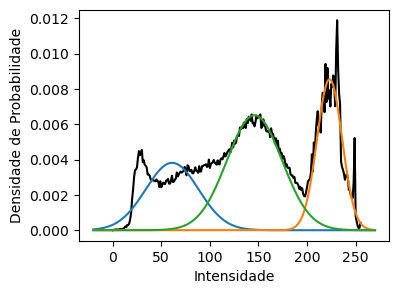

In [14]:
def gaussian_1d(x, mean, variance):
    """Calcula a função de densidade de probabilidade de uma distribuição Normal unidimensional."""
    
    sigma = variance**0.5
    gauss = np.exp(-(x - mean)**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)
    
    return gauss

def get_class_distributions(gmm, bins_model):
    """Calcula a função de densidade de probabilidade de cada classe (componente) do modelo GMM."""
    
    means = gmm.means_
    variances = gmm.covariances_
    weights = gmm.weights_
    
    dist_classes = []
    for c in range(gmm.n_components):
        prob_c = weights[c]*gaussian_1d(bins_model, means[c], variances[c])
        dist_classes.append(prob_c)
    
    return dist_classes

bins = range(257)
# density=True faz com que o histograma seja normalizado para que a área total seja igual a 1. 
# Isso transforma o histograma em uma função de densidade de probabilidade.
hist, _ = np.histogram(img, bins, density=True)

# Define o domínio para plotar as curvas das Gaussianas. 
bins_model = np.linspace(-20, 270, 500)
dist_classes = get_class_distributions(gmm, bins_model)

plt.plot(bins[:-1], hist, c="k")
for i in range(3):
    plt.plot(bins_model, dist_classes[i])
plt.xlabel("Intensidade")
plt.ylabel("Densidade de Probabilidade")

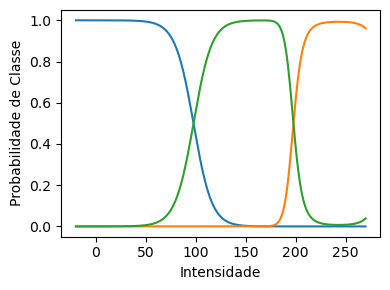

In [13]:
def get_classes_probabilities(dist_classes):
    """Calcula a probabilidade de que cada intensidade de pixel pertença a cada classe (componente) 
    do modelo GMM."""

    s = dist_classes[0]+dist_classes[1]+dist_classes[2]

    prob_classes = []
    for c in range(3):
        prob_classes.append(dist_classes[c]/s)

    return prob_classes

prob_classes = get_classes_probabilities(dist_classes)

for c in range(3):
    plt.plot(bins_model, prob_classes[c])
plt.xlabel("Intensidade")
plt.ylabel("Probabilidade de Classe")
plt.tight_layout()

O gráfico acima indica a probabilidade de que um pixel de intensidade I pertença à cada uma das classes encontradas pelo modelo de mistura de Gaussianas.

Podemos remapear essas probabilidades para a imagem original:

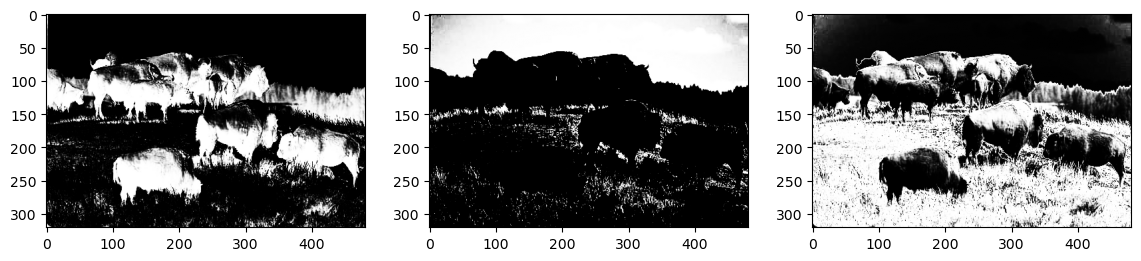

In [11]:
fig, axes = plt.subplots(1, 3, figsize=[14, 4.5])

for c in range(3):
    p = prob_classes[c][np.digitize(img.ravel(), bins_model)]
    axes[c].imshow(p.reshape(img.shape), "gray")